In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

project_folder = "diffusers_csc2210"
parent_dir = "/content/drive/MyDrive/"
working_dir = f"{parent_dir}{project_folder}"

# Clone or update the repo
if not os.path.exists(working_dir):
    print(f"Cloning into {working_dir}...")
    !git clone https://github.com/yyyyy7105/diffusers_csc2210.git {working_dir}
else:
    print("Repo exists. Updating...")
    !git -C {working_dir} pull

# Install the local codebase in editable mode
%cd {working_dir}
!pip install -e .
!pip install bitsandbytes transformers pillow


In [1]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

cache_dir = "/content/drive/MyDrive/huggingface_cache"
os.makedirs(cache_dir, exist_ok=True)
print(f"Cache directory ready: {cache_dir}")

Mounted at /content/drive
Cache directory ready: /content/drive/MyDrive/huggingface_cache


In [2]:
import os
import shutil

# ── Run this cell ONLY if from_pretrained fails with a SafetensorError /
#    "header too small" / "Unable to load weights" error.
# ── It deletes the corrupted cached download so the next cell re-downloads
#    from scratch.  Do NOT run it on a healthy cache – you'll re-download ~16 GB.

MODEL_CACHE = os.path.join(cache_dir, "models--black-forest-labs--FLUX.2-klein-4B")

if os.path.exists(MODEL_CACHE):
    shutil.rmtree(MODEL_CACHE)
    print(f"Deleted corrupted cache at:\n  {MODEL_CACHE}")
    print("Re-run the next cell to download fresh weights.")
else:
    print("No cached model found — nothing to clean up.")

No cached model found — nothing to clean up.


In [3]:
import torch
from diffusers import Flux2KleinPipeline, PipelineQuantizationConfig
from transformers import BitsAndBytesConfig

device = "cuda"
print(f"{torch.cuda.is_available()=}")
dtype = torch.float16
enable_profiler = False
print(f"{enable_profiler=}")

# Configure 4-bit quantization using BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=dtype
)

quantization_config = PipelineQuantizationConfig(quant_backend="bitsandbytes_4bit", quant_kwargs=bnb_config.to_dict())

pipe = Flux2KleinPipeline.from_pretrained("black-forest-labs/FLUX.2-klein-4B", cache_dir=cache_dir, quantization_config=quantization_config, torch_dtype=dtype, enable_profiler=enable_profiler)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


torch.cuda.is_available()=True
enable_profiler=False


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

I am running in: /content
I am looking for logs at: /content/log/flux2_profile


  0%|          | 0/4 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/flux_outputs/flux-klein_20260308_222423.png


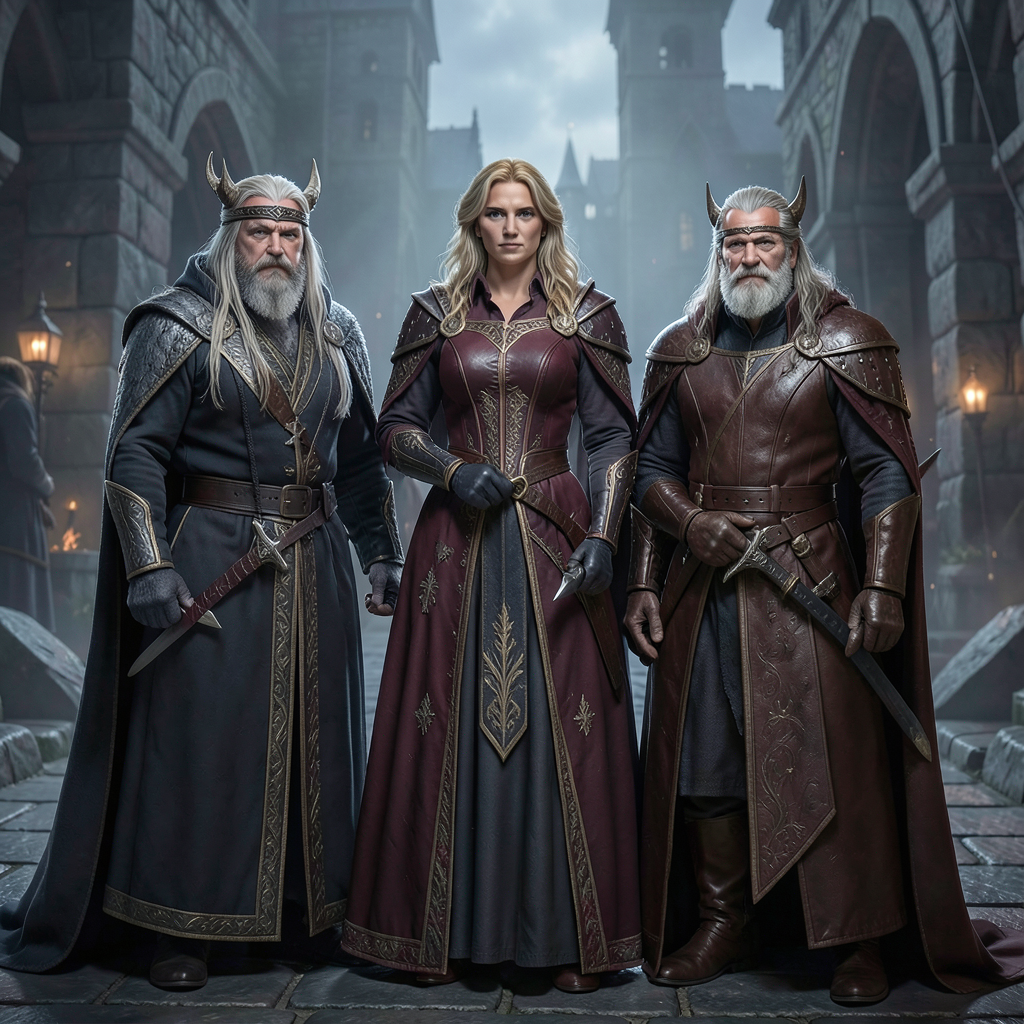

In [16]:
from PIL import Image
import torch
import os
from datetime import datetime

# Placeholder for your initial image. Replace with your actual image variable or path.
# For example: from PIL import Image; initial_image = Image.open("path/to/your/image.png")
# initial_image = Image.open("/content/Screenshot 2026-02-10 194248.png") # Please provide your initial image here. OPTIONAL

prompt = "Make a picture of the main characters in the game of the thrones"
image = pipe(
    prompt=prompt,
    # image=initial_image,  # OPTIONAL
    height=1024,
    width=1024,
    guidance_scale=1.0,
    num_inference_steps=4, 
    generator=torch.Generator(device=device).manual_seed(0)
).images[0]

# Save to Google Drive with a timestamped filename
output_dir = "/content/drive/MyDrive/flux_outputs"
os.makedirs(output_dir, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_path = os.path.join(output_dir, f"flux-klein_{timestamp}.png")
image.save(output_path)
print(f"Saved to: {output_path}")
image

In [ ]:
!du -sh /content/drive/MyDrive/huggingface_cache

15G	/content/drive/MyDrive/huggingface_cache


In [ ]:
profile = pipe.get_profile()